<a href="https://colab.research.google.com/github/sundaybest3/txtanalysis/blob/function_position/position_frequency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

url = 'https://raw.githubusercontent.com/sundaybest3/txtanalysis/refs/heads/function_position/High_School_Textbook_Dialogue_data_first_analysis.csv'

# Position 열 확인
print(df_textbook.columns)

# 'Position_B' 컬럼의 공백 제거 및 빈도표 생성
df_textbook['position1'] = df_textbook['position1'].str.strip()
position_counts_textbook = df_textbook['position1'].value_counts().sort_index()

# Exclude '10' and '135' from position_counts_textbook
position_counts_textbook = position_counts_textbook[~position_counts_textbook.index.isin(['10', '135'])]

print(position_counts_textbook)

textbook_position_data = position_counts_textbook.reset_index()
textbook_position_data.columns = ['Position', 'Frequency']

# 백분율 계산 및 추가
total_count_textbook = textbook_position_data['Frequency'].sum()
textbook_position_data['Percentage'] = (textbook_position_data['Frequency'] / total_count_textbook * 100).round(2)

print(textbook_position_data)

Index(['Publisher', 'Author', 'Grade Level', 'Lesson No.', 'Section Title',
       'Subsection', 'Label', 'Conversation ID', 'Speech type', 'Turn No.',
       'Speaker', 'Script', 'Word Count', 'position1', 'function1',
       'position2', 'function2', 'Consistency', 'agreement', 'corpus'],
      dtype='object')
position1
TI     10
UI    135
UM     10
Name: count, dtype: int64
  Position  Frequency  Percentage
0       TI         10        6.45
1       UI        135       87.10
2       UM         10        6.45


In [ ]:
import pandas as pd

sbcsae_urls = [
    "https://raw.githubusercontent.com/sundaybest3/txtanalysis/refs/heads/function_position/cleaned_sbcase_47_1.csv",
    "https://raw.githubusercontent.com/sundaybest3/txtanalysis/refs/heads/function_position/cleaned_sbcase_49_1.csv",
    "https://raw.githubusercontent.com/sundaybest3/txtanalysis/refs/heads/function_position/cleaned_sbcase_50_1.csv",
    "https://raw.githubusercontent.com/sundaybest3/txtanalysis/refs/heads/function_position/cleaned_sbcase_51_1.csv",
    "https://raw.githubusercontent.com/sundaybest3/txtanalysis/refs/heads/function_position/cleaned_sbcase_56_1.csv",
]

combined = pd.DataFrame()

for url in sbcsae_urls:
    df = pd.read_csv(url)
    combined = pd.concat([combined, df], ignore_index=True)

sbcsae_position_counts = combined["position1"].value_counts().reindex(["TI", "UI", "UM", "TF"])

sbcsae_position_data = sbcsae_position_counts.reset_index()
sbcsae_position_data.columns = ['Position', 'Frequency']

# Calculate total count for SBCSAE
total_count_sbcsae = sbcsae_position_data['Frequency'].sum()

# Calculate Percentage for SBCSAE
sbcsae_position_data['Percentage'] = (sbcsae_position_data['Frequency'] / total_count_sbcsae * 100).round(2)

print("SBCSAE Position Frequencies and Percentages:")
print(sbcsae_position_data)
print(f"\nTotal: {total_count_sbcsae}")

SBCSAE Position Frequencies and Percentages:
  Position  Frequency  Percentage
0       TI         67       32.68
1       UI        132       64.39
2       UM          2        0.98
3       TF          4        1.95

Total: 205


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# Observed frequency table
observed = np.array([
    [10, 135, 10, 0],   # Textbook
    [67, 132, 2, 4]     # SBCSAE
])

positions = ["TI", "UI", "UM", "TF"]
corpora = ["Textbook", "SBCSAE"]

# Chi-square test
chi2, p, dof, expected = chi2_contingency(observed)

print("Chi-square:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p)

# Expected frequencies
expected_df = pd.DataFrame(expected, index=corpora, columns=positions)

print("\nExpected frequencies:\n")
print(expected_df)

# Standardized residuals
std_residuals = (observed - expected) / np.sqrt(expected)

residuals_df = pd.DataFrame(std_residuals, index=corpora, columns=positions)

print("\nStandardized residuals:\n")
print(residuals_df)

Chi-square: 45.495006235819005
Degrees of freedom: 3
p-value: 7.2620011624815e-10

Expected frequencies:

                 TI          UI        UM        TF
Textbook  33.152778  114.958333  5.166667  1.722222
SBCSAE    43.847222  152.041667  6.833333  2.277778

Standardized residuals:

                TI        UI        UM        TF
Textbook -4.021084  1.869234  2.126383 -1.312335
SBCSAE    3.496488 -1.625371 -1.848972  1.141126


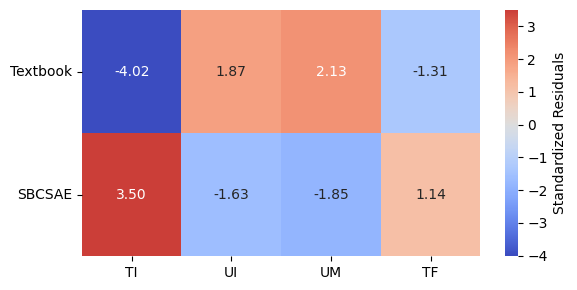

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))

sns.heatmap(
    residuals_df, # Do NOT transpose the DataFrame
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    cbar_kws={"label": "Standardized Residuals"}
)


plt.yticks(rotation=0) # Ensure y-axis labels are horizontal

plt.tight_layout()
plt.savefig('/content/standardized_residuals_heatmap.png') # Save the heatmap as a PNG file
plt.show()